# 1. Windsor, Ontario — Residential House Price Prediction:
**Author:** Van Suriyo &nbsp;|&nbsp; **Dataset:** 546 Homes in Windsor, Ontario, Canada

---

## I. Introduction & Business Problem

The Windsor housing market, like many mid-sized Canadian cities, presents a valuable opportunity for data-driven decision-making. This project builds and compares four regression models — **Linear Regression, Ridge Regression, Random Forest, and Gradient Boosting** — to predict residential sale prices from property attributes.

**Stakeholders who benefit from this analysis:**
- **Buyers** — understand what features drive price premiums
- **Sellers** — identify which improvements yield the highest return
- **Real estate agents** — set data-backed listing prices with confidence

The dataset contains **546 transactions** across **12 features** including lot size, bedrooms, bathrooms, stories, and binary amenities (driveway, air conditioning, garage, etc.).

### Libraries and Imports

In [25]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Machine Learning Libraries
from sklearn.preprocessing import StandardScaler
from sklearn import preprocessing, metrics
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline

# 2. Data Loading and Data Cleaning

In [50]:
# Create a dataframe from the CSV file
df = pd.read_csv("/kaggle/input/house-prices-in-the-city-of-windsor-canada/HousePrices.csv", index_col=0)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


The raw data consist of 546 rows with 12 columns of marketable attributes

## I. Data Cleaning

In [51]:
# Data Cleaning
df.dropna(inplace=True) # If necessary delete empty cells

In [28]:
# Confirmation for any leftover missing data or unbalanced dimensions
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 546 entries, 1 to 546
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   price       546 non-null    float64
 1   lotsize     546 non-null    int64  
 2   bedrooms    546 non-null    int64  
 3   bathrooms   546 non-null    int64  
 4   stories     546 non-null    int64  
 5   driveway    546 non-null    object 
 6   recreation  546 non-null    object 
 7   fullbase    546 non-null    object 
 8   gasheat     546 non-null    object 
 9   aircon      546 non-null    object 
 10  garage      546 non-null    int64  
 11  prefer      546 non-null    object 
dtypes: float64(1), int64(5), object(6)
memory usage: 55.5+ KB


In [29]:
# Dropping columns and transform the yes/no object-oriented string to numerical values
# Binary Coding of features
df_eda = df.copy() # Preserved the original dataframe

binary_cols = ['driveway','recreation','fullbase','gasheat','aircon','prefer']
df_eda[binary_cols] = df_eda[binary_cols].apply(lambda col: col.map({'yes': 1, 'no': 0}))

df_eda.info()

<class 'pandas.core.frame.DataFrame'>
Index: 546 entries, 1 to 546
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   price       546 non-null    float64
 1   lotsize     546 non-null    int64  
 2   bedrooms    546 non-null    int64  
 3   bathrooms   546 non-null    int64  
 4   stories     546 non-null    int64  
 5   driveway    546 non-null    int64  
 6   recreation  546 non-null    int64  
 7   fullbase    546 non-null    int64  
 8   gasheat     546 non-null    int64  
 9   aircon      546 non-null    int64  
 10  garage      546 non-null    int64  
 11  prefer      546 non-null    int64  
dtypes: float64(1), int64(11)
memory usage: 55.5 KB


In [30]:
# Statistics Summary of numerical data to 3 decimal places
df_eda.describe().round(3)

,price,lotsize,bedrooms,bathrooms,stories,driveway,recreation,fullbase,gasheat,aircon,garage,prefer
count,546.000,546.000,546.000,546.000,546.000,546.000,546.000,546.000,546.000,546.000,546.000,546.000
mean,68121.597,5150.266,2.965,1.286,1.808,0.859,0.178,0.350,0.046,0.317,0.692,0.234
std,26702.671,2168.159,0.737,0.502,0.868,0.348,0.383,0.477,0.209,0.466,0.861,0.424
min,25000.000,1650.000,1.000,1.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,49125.000,3600.000,2.000,1.000,1.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000
50%,62000.000,4600.000,3.000,1.000,2.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000
75%,82000.000,6360.000,3.000,2.000,2.000,1.000,0.000,1.000,0.000,1.000,1.000,0.000
max,190000.000,16200.000,6.000,4.000,4.000,1.000,1.000,1.000,1.000,1.000,3.000,1.000


**Reflections :**
- The housing price ranges from 25,000 dollars  to 190,000 dollars with a mean of ~68,000 dollars, this tells us the dataset was compiled a long while ago.

**Re-Labeled :**
- Cells with Yes/No object oriented datatype are dropped for later binary encoding.

# 3. Exploratory Data Analysis
## I. Pricing

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


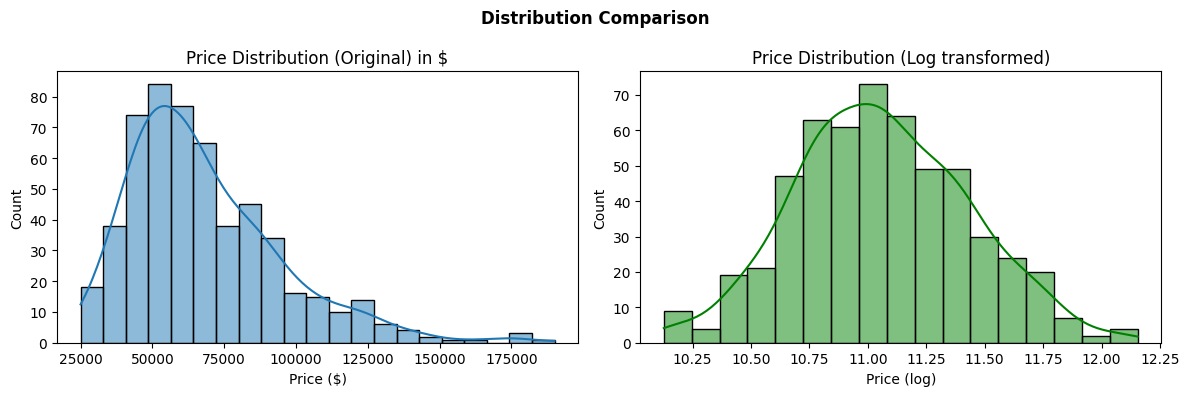

In [53]:
# Pricing Histogram
fig, axes = plt.subplots(1,2, figsize = (12,4))

sns.histplot(df_eda['price'],ax = axes[0], kde = True)
axes[0].set_title("Price Distribution (Original) in $")
axes[0].set_xlabel("Price ($)")

sns.histplot(np.log1p(df_eda['price']), kde = True, ax = axes[1], color = 'green')
axes[1].set_title("Price Distribution (Log transformed)")
axes[1].set_xlabel("Price (log)")

plt.suptitle("Distribution Comparison", fontweight = 'bold')
plt.tight_layout()
plt.show()

**Exploratory Data Analysis Observations:**

- The raw Prices inputs follows a Right-Skewed Distribution, means a small number of expensive houses pulls the mean upwards. The log transform graph displays a Gaussian distribution.

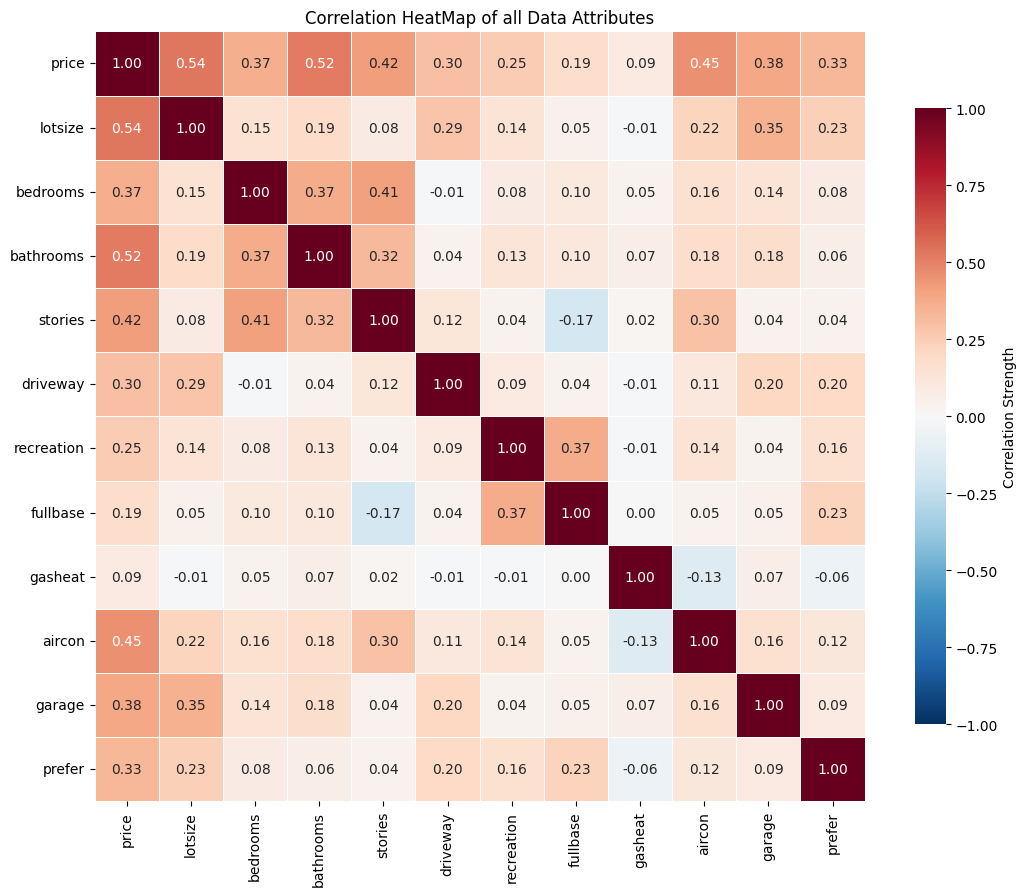

In [54]:
# Attributes relationship exploration

# Plotting heatmap
corr_housing =df_eda.corr(numeric_only = True)
plt.figure(figsize=(13,10))
sns.heatmap(
    corr_housing,
    annot=True,
    cmap = "RdBu_r", # poor relationship = blue, good relationship = red
    vmin = -1,
    vmax = 1,
    center = 0,
    square = True,
    linecolor = 'white',
    linewidths = 0.5,
    fmt=".2f",
    cbar_kws = {"shrink": 0.8, "label": "Correlation Strength"}
)
plt.title("Correlation HeatMap of all Data Attributes")
plt.show()

**Analysis :**
The Pricing column has the best relationship with lotsize (0.54) and amounts of bathrooms (0.52). The weakest link is gasheat,  meaning it adds the minimal difference to pricing signal.

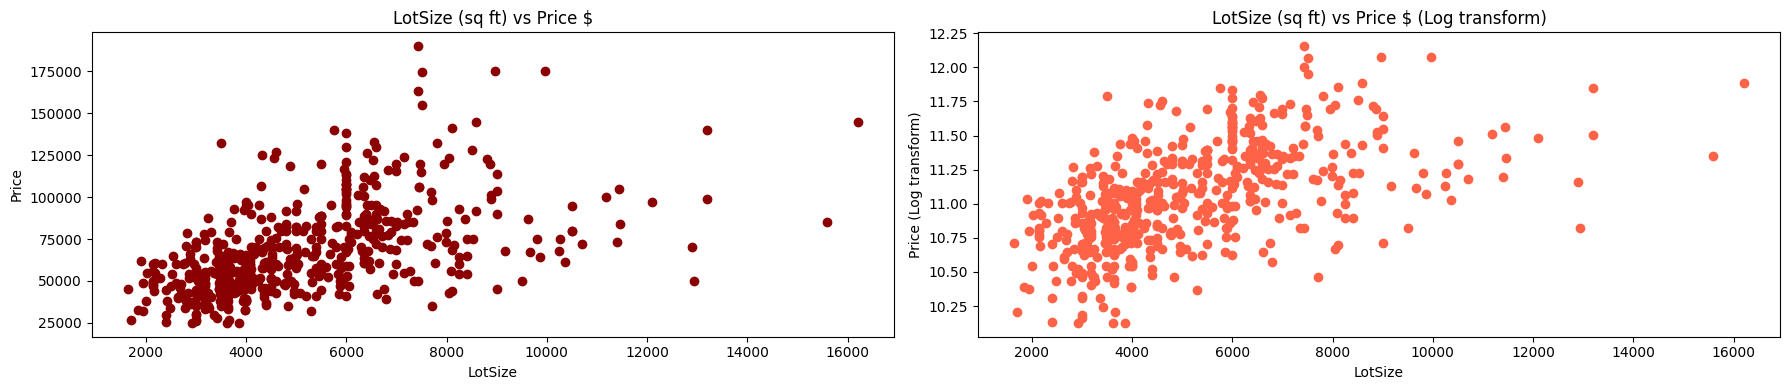

In [52]:
# Price vs Lotsize

fig, axes = plt.subplots(1,2, figsize = (18,4))

axes[0].scatter(df_eda['lotsize'], df_eda['price'], color = 'darkred')
axes[0].set_title("LotSize (sq ft) vs Price $")
axes[0].set_xlabel("LotSize")
axes[0].set_ylabel("Price")

axes[1].scatter(df_eda['lotsize'], np.log1p(df_eda['price']), color = 'tomato')
axes[1].set_title("LotSize (sq ft) vs Price $ (Log transform)")
axes[1].set_xlabel("LotSize")
axes[1].set_ylabel("Price (Log transform)")

plt.tight_layout()
plt.show()

**Analysis** : The linear relationship between Price and Lotsize are more apparent.

## II. More Exploratory Data Analysis

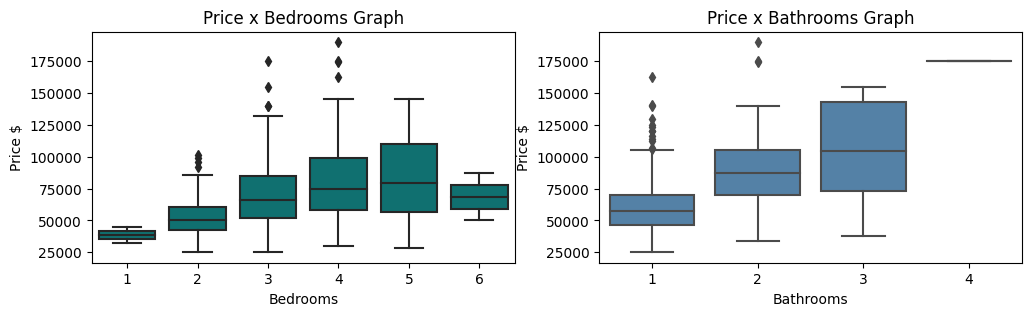

In [34]:
 fig, axes = plt.subplots(1,2, figsize = (12,3))

 sns.boxplot(x = 'bedrooms', y = 'price', data = df_eda, color = 'teal', ax = axes[0])
 axes[0].set_title("Price x Bedrooms Graph")
 axes[0].set_xlabel("Bedrooms")
 axes[0].set_ylabel("Price $")

 sns.boxplot(x = 'bathrooms', y = 'price', data = df_eda, color = 'steelblue', ax = axes[1])
 axes[1].set_title("Price x Bathrooms Graph")
 axes[1].set_xlabel("Bathrooms")
 axes[1].set_ylabel("Price $")

 plt.tight_layout()
 plt.show()

**Analysis :** Median house price seems to rise when both bathrooms and bedrooms amount increases. The exception is when we have 6 bedrooms, this anomaly could be argued that more bedrooms signifies smaller rooms size. The amount of Bathrooms is proportional to Price.

## III. Do the Amenities Impact the Price ?
Amenities such as driveway, air conditioner, recreation centre, gas heat, and fully finished basement are place in binary format (Yes/No). Do they impact the Price ?

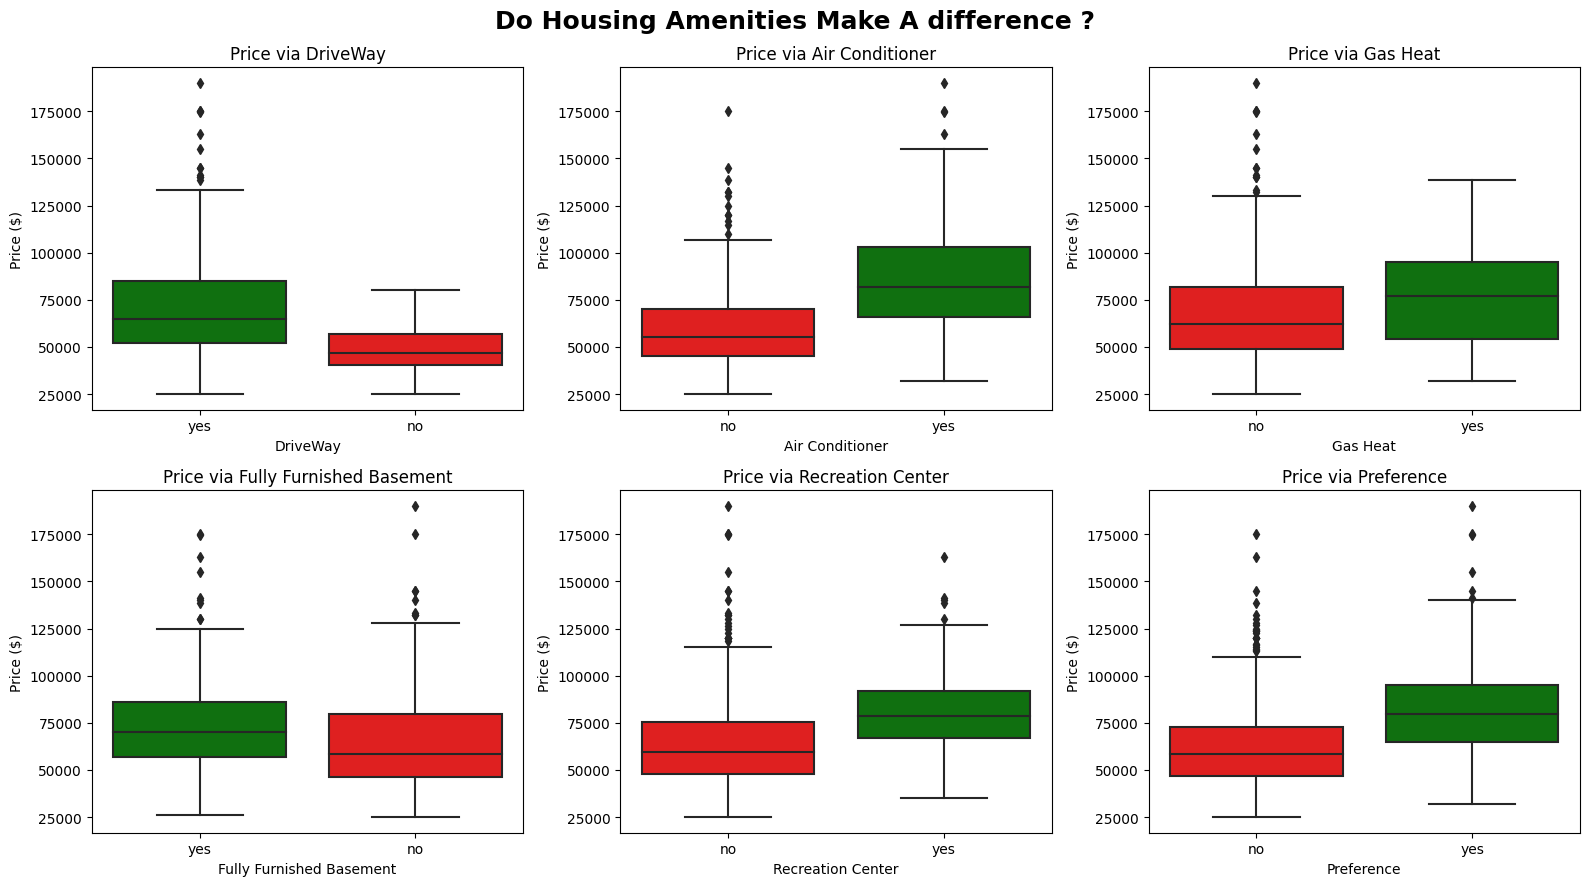

In [35]:
amenities = ['driveway', 'aircon','gasheat', 'fullbase', 'recreation', 'prefer']
amenities_fullname = ['DriveWay', "Air Conditioner", "Gas Heat", "Fully Furnished Basement", "Recreation Center", "Preference"]

fig, axes = plt.subplots(2,3, figsize = (16,9))
plt.suptitle("Do Housing Amenities Make A difference ?", fontweight = 'bold', fontsize = 18)
axes = axes.flatten()

for i, cols in enumerate(amenities):
    sns.boxplot(x = cols, y = 'price', data = df, palette = {"yes": "green","no": "red"}, ax = axes[i]) # in pycharm remove x = cols, add hue = cols
    axes[i].set_title(f"Price via {amenities_fullname[i]}")
    axes[i].set_xlabel(amenities_fullname[i])
    axes[i].set_ylabel("Price ($)")

plt.tight_layout()
plt.show()

**Analysis :** The Driveway and Air Conditioner carry a higher price premium because Windsor is a small metropolitan city where most of the population commute to work. Ontarians experience two extremes, summers are hot, thus the value for air conditioner, another premium. Winters are cold, but gas heat have an alternative competing appliance that is easier to setup and more efficient to run called electric heater, hence the so-so gas heat graph.

# 4. Data Preprocessing and Feature Engineering

## I. Label Encoder

In [36]:
# Binary Encoding by Label Encoder

X = df.drop(['price', 'driveway', 'recreation', 'fullbase', 'gasheat', 'aircon', 'prefer'], axis=1)

le = preprocessing.LabelEncoder()

# Note, garage is already a numerical value, thus it will be passed on instead
# Using a label encoder to categorize object oriented values (yes/no) into binary numbers
for cols in ['driveway', 'recreation', 'fullbase', 'gasheat', 'aircon', 'prefer']:
    X[cols] = le.fit_transform(df[cols])

y = df['price'].astype('int64') # Consistent datatype for all variables

## II. Feature Engineering

Why Feature Engineering
- Some relationship between attributes are compounding. e.g. A house sitting on a large lot size with more bedrooms and bathrooms are more attractive to a families (double income) then a bachelor's (single income) who values spacing.

In [37]:
# Engineers Features

X['lotsize_log'] = np.log1p(X['lotsize'])
X['total_rooms'] = X['bedrooms'] + X['bathrooms'] # The more the better
X['bath_bed_ratio'] = X['bathrooms'] / (X['bedrooms']+1) # Typically, More bathrooms per bedrooms means higher-end homes
X['stories_x_bedrooms'] = X['stories'] * X['bedrooms'] # Spacing efficiency
X['garage_x_aircon'] = X['garage'] * X['aircon'] # Garages and Air Conditioners are premium features, both means much higher quality house

print(f"New Dimension : {X.shape}")

New Dimension : (546, 16)


| `Feature`                 | Rationale                                                                                         |
|-------------------------|---------------------------------------------------------------------------------------------------|
| `Lot Size Log`            | Log transformation is needed to reduce the skewness and improve model performance                 |
| `Total Rooms`             | Combined the bedrooms and bathrooms amount; a premium to attract large families                   |
| `Bathrooms : Bedrooms`    | A higher ratio typically signifies higher-end homes                                               |
| `Garage x Air Conditioner` |From the heatmap, two amenities most corelated with price, both will command disproportionate premiums |

# 5. Machine Learning 
## I. Train / Test Split and Scaling
- A 70/30 Train/Test split was used because it offered best score and random_state = 42 for reproducibility

In [38]:
#%%
sc = StandardScaler()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30, random_state = 42)

X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)

print(f"Training Samples : {X_train_sc.shape[0]} |", f"Testing Samples : {X_test_sc.shape[0]}")

Training Samples : 382 | Testing Samples : 164


## II. Model Building & Computation

Two linear and Two tree based models are trained. They are Linear, Ridge, Random Forest, and Gradient Boost respectively. This breadth will help determined if the underlying house pricing is linear or non-linear.

In [39]:
# Model 1 : Linear Regression Model
lr = LinearRegression()
lr.fit(X_train_sc, y_train)
print("Linear Regressor Completed")

Linear Regressor Completed


In [40]:
# Model 2 : Ridge Regression Model
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_sc, y_train)
print("Ridge Regressor Completed")

Ridge Regressor Completed


In [41]:
# Model 3 : Random Forest Regression
rfr = RandomForestRegressor(random_state=42)
rfr.fit(X_train_sc, y_train)
print("Random Forest Regressor Completed")

Random Forest Regressor Completed


In [42]:
# Model 4 : Gradient Boost Regression
gbr = GradientBoostingRegressor(
    n_estimators   = 300,
    learning_rate  = 0.03,
    max_depth      = 3,
    min_samples_split = 2,
    subsample      = 0.8,
    random_state   = 42
)
gbr.fit(X_train_sc, y_train)
print("Gradient Boosting Regressor Completed")

Gradient Boosting Regressor Completed


## III. GridSearchCV

In [43]:
# GridSearchCV : Hypertuning for Multiple Models via Pipeline

grid_configs = {
    "Ridge": {
        "model": Ridge(),
        "params": {
            "regressor__alpha": [1, 10, 100],
            "regressor__fit_intercept": [True, False]
        }
    },
    "RandomForest": {
        "model": RandomForestRegressor(random_state=42),
        "params": {
            "regressor__n_estimators": [100, 300],
            "regressor__max_depth": [5, 10],
            "regressor__min_samples_split": [2, 5],
            "regressor__max_features": ["sqrt", "log2"]
        }
    }
}
grid_results = [] # Storing GridSearchCV in a dictionary
best_estimators = {} # storing fitted estimators by model names

In [44]:
# Loop through the Models

for model_name, config in grid_configs.items():
    print(f"\n{'='*50}")
    print(f"Training: {model_name}")
    print(f"{'='*50}")

    # Pipeline
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("regressor", config["model"])
    ])
    grid_search = GridSearchCV(
        estimator = pipeline,
        param_grid = config["params"],
        cv = 5,
        scoring = "neg_mean_squared_error",
        n_jobs = -1,
        verbose = 1
    )
    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_

    test_score = best_model.score(X_test, y_test)

    cv_rmse = np.sqrt(-grid_search.best_score_)

    best_estimators[model_name] = best_model

    grid_results.append({
        "Model":    model_name,
        "Best Params": grid_search.best_params_,
        "CV RMSE": round(cv_rmse,4),
        "Test R^2": round(test_score,4),
        "Best Estimator": best_model,
    })

    print(f"Best Parameters : {grid_search.best_params_}")
    print(f"CV RMSE : {cv_rmse:4f}")
    print(f"Test R^2 : {test_score:4f}")


Training: Ridge
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best Parameters : {'regressor__alpha': 100, 'regressor__fit_intercept': True}
CV RMSE : 15943.039572
Test R^2 : 0.713170

Training: RandomForest
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Parameters : {'regressor__max_depth': 10, 'regressor__max_features': 'sqrt', 'regressor__min_samples_split': 5, 'regressor__n_estimators': 300}
CV RMSE : 16881.556026
Test R^2 : 0.663890


## IV. Model Evaluation
Three Different Metrics are used to provide a picture of the Model's Performance | Explainer

- R^2   | higher is better, up to a max of 1.0
- Mean Absolute Error   | average absolute error (lower = better, shown in $
- Root Mean Square Error    | measure the difference between predicted and actual 'truth' in regression models, lower = better

## V. Predictions

In [45]:
# All Models
predict_lr = lr.predict(X_test_sc)
predict_ridge = ridge.predict(X_test_sc)
predict_rfr = rfr.predict(X_test_sc)
predict_gbr = gbr.predict(X_test_sc)

# best_estimators Prediction
predict_ridge_grid = best_estimators["Ridge"].predict(X_test) # X_test instead of X_test_sc to avoid overfitting
predict_rfr_grid = best_estimators["RandomForest"].predict(X_test)

Pipeline includes its own StandardScaler, so the raw X_test is passed instead to avoid double-scaling


## VI. Results & Observations

In [46]:
# Results Table
def evaluate_model(name, y_true, y_pred):
    return {
        "Model" : name,
        "R^2" : round(metrics.r2_score(y_true, y_pred), 4),
        "MAE" : round(metrics.mean_absolute_error(y_true, y_pred), 0),
        "RMSE" : round(np.sqrt(metrics.mean_squared_error(y_true, y_pred)), 0),
    }

evaluate_df = pd.DataFrame([
    evaluate_model("Linear Regression", y_test, predict_lr),
    evaluate_model("Ridge Regression", y_test, predict_ridge),
    evaluate_model("Random Forest", y_test, predict_rfr),
    evaluate_model("Gradient Boosting", y_test, predict_gbr),
    evaluate_model("Random Forest (GridSearchCV)", y_test, predict_rfr_grid),
    evaluate_model("Ridge Regression (GridSearchCV)", y_test, predict_ridge_grid),
]).sort_values("R^2", ascending = False).reset_index(drop = True)
print(evaluate_df.to_string(index=False))

                          Model    R^2     MAE    RMSE
Ridge Regression (GridSearchCV) 0.7132 11432.0 15629.0
               Ridge Regression 0.7109 11433.0 15692.0
              Linear Regression 0.7098 11444.0 15720.0
              Gradient Boosting 0.6647 12116.0 16897.0
   Random Forest (GridSearchCV) 0.6639 12167.0 16919.0
                  Random Forest 0.6288 12669.0 17780.0


**Analysis :**
- Ridge and Linear Regression models outperform both tree based models. This tells us the Housing Price are mainly linear
- The tiny gaps (~0.08) between the Best and worst R^2 score confirms that all models capture similar information and the limit is probably the dataset sample size
- The mean absolute error best model is only off by a tens of thousands of dollar, valuable information for both buyers and sellers.

**Improvements :**
- Because of the tiny gaps between linear and tree based models, we can argue the dataset is too small
- Key features are missing such as ; age of the house, interior/exterior condition, neighbourhoods, crime and safety.

# 6. Summary
## I. Predicted vs Actual

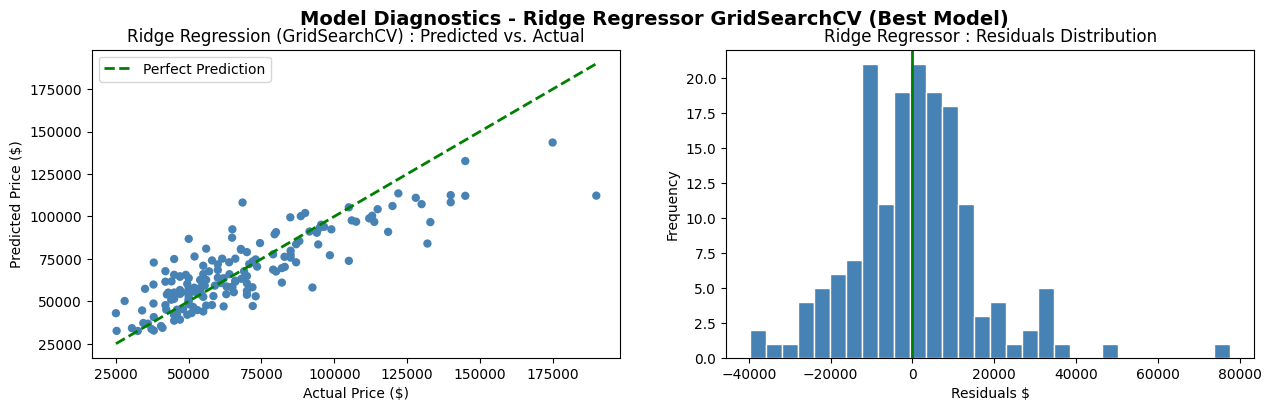

In [47]:
# Actual vs Predicted - Visualization Graph with Residual Check
fig, axes = (plt.subplots(1,2, figsize = (15,4)))

# Predicted vs Actual House Price Graph
axes[0].scatter(y_test, predict_ridge_grid, alpha=1.0, color='steelblue', edgecolors='none')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'g--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel("Actual Price ($)")
axes[0].set_ylabel("Predicted Price ($)")
axes[0].set_title("Ridge Regression (GridSearchCV) : Predicted vs. Actual")
axes[0].legend()

# Residual
residuals = y_test - predict_ridge_grid
axes[1].hist(residuals, bins=30, color='steelblue', edgecolor='white')
axes[1].set_title("Ridge Regressor : Residuals Distribution")
axes[1].set_xlabel("Residuals $")
axes[1].set_ylabel("Frequency")
axes[1].axvline(0, color='green', lw=2)

plt.suptitle("Model Diagnostics - Ridge Regressor GridSearchCV (Best Model)", fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.show()

**Diagnostics Analysis :** The predicted and actual plot shows overlapping track. Especially in the low to mid-range house pricing before breaking away at the higher-end homes. The residuals centered around 0, which implies no systematic bias. The slight right skewed residuals could be due to the higher end value homes being under predicted.

## II. Which Feature(s) Are Important

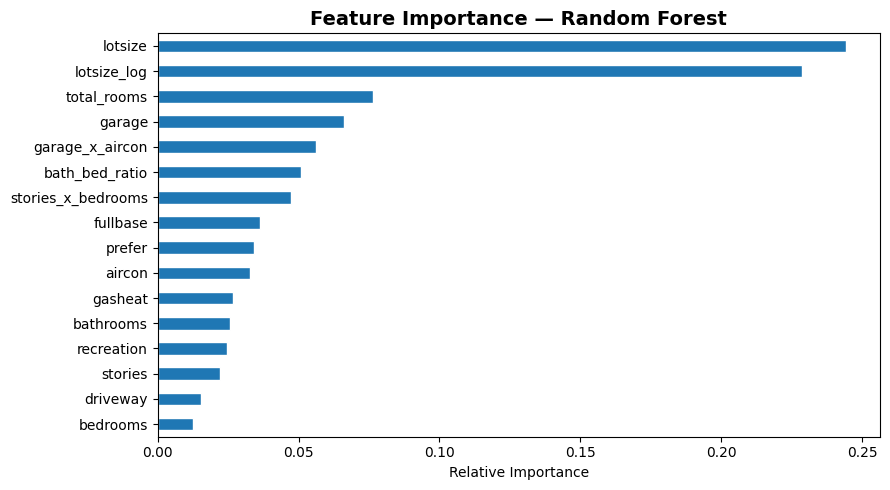

In [48]:
### Feature Importance - Random Forest
feature_importance = pd.Series(
    rfr.feature_importances_, index=X.columns).sort_values(ascending=True
)

fig, ax = plt.subplots(figsize=(9, 5))
feature_importance.plot(kind='barh', ax=ax, edgecolor='white')
ax.set_title("Feature Importance — Random Forest", fontsize=14, fontweight='bold')
ax.set_xlabel("Relative Importance")
plt.tight_layout()
plt.show()

**Analysis** : The lot size dominate the important features, reinforcing the exploratory data analysis observation. The Engineered feature of bath__bed_ratio, total_rooms and garage_x_aircon appear in the top half of the graph, validating the significance of the featured engineering efforts.

## III. Reports and Buyer/Sellers Recommendations

### What the data says :

1. The lot size is the upmost strongest predictor of what's driving the price, by a large margin. Buyers seeking value should priorities smaller lots; sellers with large lot size should maximize price potential.
2. Bathrooms matter more than bedrooms. A higher bathroom to bedrooms ratio is a nice proxy for higher-end homes.
3. Garage and Air Conditioners command a premiums. Homes with garage signifies higher median price. This could mean Windsor is not a complete metropolitan; typically in big cities high rises building also command higher prices due to location.
4. Linear Models (Ridge, Linear) outperforms tree-based models (Random Forest, Gradient Boost) here. The near linear scatter plot shows us so.
5. Improvements on Score: The R^2 score of ~.71 (Ridge) could be significantly improve with key features. The remaining ~29% is most likely attributed to missing important features - property age, interior condition, exterior condition, school district zone, and neighbourhood effect.